In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor

In [2]:
df = pd.read_csv('insurance_pre.csv')
df.head(5)

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520


In [3]:
print("Shape of the Dateset :",df.shape)
print("Rows :", df.shape[0])
print("Columns :",df.shape[1])
print("\nDataset Columns and Types:")
print(df.dtypes)

Shape of the Dateset : (1338, 6)
Rows : 1338
Columns : 6

Dataset Columns and Types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
charges     float64
dtype: object


In [4]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
charges     0
dtype: int64

In [5]:
df=df.drop_duplicates().reset_index(drop=True)
df.head()

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520


In [6]:
for column in df.select_dtypes(include=['object']).columns:
    print(f"{column} : {df[column].unique()}")

sex : ['female' 'male']
smoker : ['yes' 'no']


In [7]:
df['sex'] = df['sex'].map({'female': 0, 'male': 1})
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})

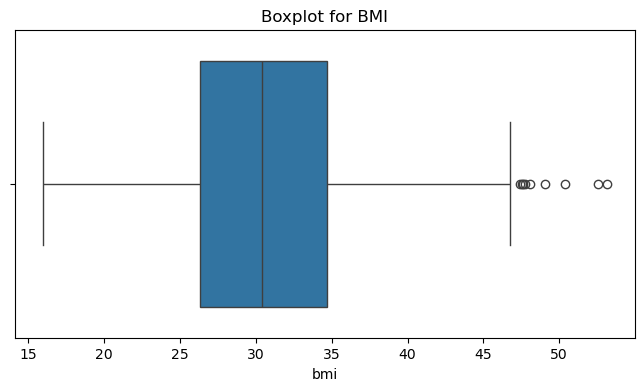

In [8]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['bmi'])
plt.title("Boxplot for BMI")
plt.show()

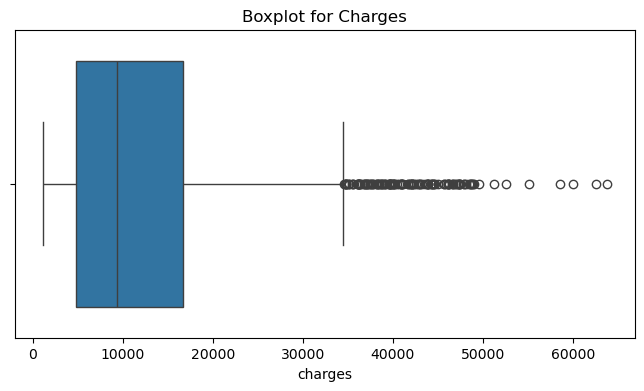

In [9]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['charges'])
plt.title("Boxplot for Charges")
plt.show()

In [10]:
numerical_cols = [ 'bmi', 'charges']
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_limit) & (df[col] <= upper_limit)]

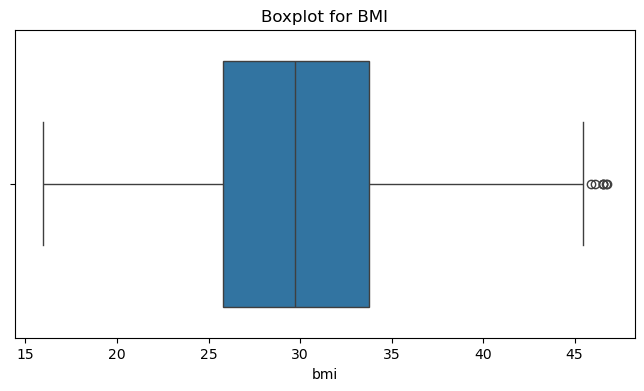

In [11]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['bmi'])
plt.title("Boxplot for BMI")
plt.show()

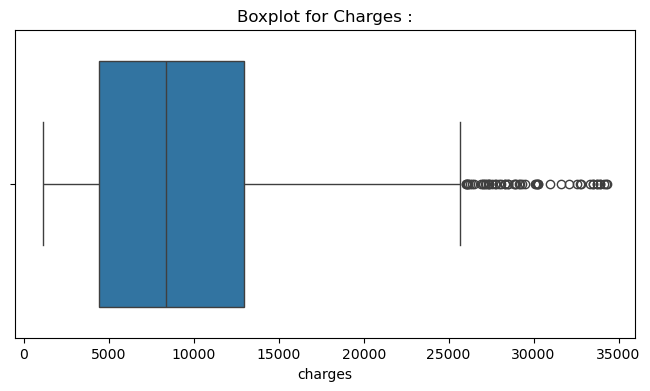

In [12]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['charges']) 
plt.title("Boxplot for Charges :")
plt.show()

In [13]:
X = df[['age','sex','bmi','children','smoker']]
y = df['charges']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0)

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
lr_regressor = LinearRegression()
lr_regressor.fit(X_train, y_train)
lr_pred = lr_regressor.predict(X_test)
r_score_lr=r2_score(y_test,lr_pred)

In [17]:
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor()
regressor=regressor.fit(X_train,y_train)
y_pred=regressor.predict(X_test)
r_score=r2_score(y_test,y_pred)

In [18]:
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=0)
rf_regressor.fit(X_train, y_train)
rf_pred = rf_regressor.predict(X_test)
rf_score = r2_score(y_test, rf_pred)

In [19]:
print("LinearRegression r_score :",r_score_lr)
print("DecisionTreeRegressor r_score: ", r_score)
print("RandomForestRegressor r_score :", rf_score)

LinearRegression r_score : 0.6290343292648193
DecisionTreeRegressor r_score:  0.2453516878713632
RandomForestRegressor r_score : 0.5294505584307553


In [20]:
model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=0)
model.fit(X_train_scaled, y_train)
gr_pred= model.predict(X_test_scaled)
gr_score = r2_score(y_test, gr_pred)

In [21]:
ada_model = AdaBoostRegressor(n_estimators=100, random_state=0)
ada_model.fit(X_train_scaled, y_train)
ada_pred = ada_model.predict(X_test_scaled)
ada_score = r2_score(y_test, ada_pred)

In [22]:
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=0)
xgb_model.fit(X_train_scaled, y_train)
xgb_pred = xgb_model.predict(X_test_scaled)
xgb_score = r2_score(y_test, xgb_pred)

In [23]:
print(f"GradientBoosting r_score : {gr_score}")
print(f"AdaBoostRegressor r_score  : {ada_score}")
print(f"XGBRegressor r_score      : {xgb_score}")

GradientBoosting r_score : 0.612440580499698
AdaBoostRegressor r_score  : 0.5359193349943604
XGBRegressor r_score      : 0.6498559046951529


In [24]:
model_results = [
    ("Linear Regression", r_score_lr),
    ("Decision Tree", r_score),
    ("Random Forest", rf_score),
    ("Gradient Boosting", gr_score),
    ("AdaBoost", ada_score),
    ("XGBoost", xgb_score)
]

model_results.sort(key=lambda x: x[1], reverse=True)
print(f"{'Model Name':<25} | {'R2 Score':<10}")
print("-" * 40)
for name, score in model_results:
    print(f"{name:<25} | {score:.4f}")

best_model, best_score = model_results[0]
print("-" * 40)
print(f"THE BEST PREDICTION MODEL IS: {best_model} ({best_score:.4f})")

Model Name                | R2 Score  
----------------------------------------
XGBoost                   | 0.6499
Linear Regression         | 0.6290
Gradient Boosting         | 0.6124
AdaBoost                  | 0.5359
Random Forest             | 0.5295
Decision Tree             | 0.2454
----------------------------------------
THE BEST PREDICTION MODEL IS: XGBoost (0.6499)
